In [2]:
import torch as th
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

In [19]:
with open ('data/funky.csv', 'rb') as f:
  all_data = np.loadtxt(f, delimiter=",", dtype="float32")

data = dict()
data["x"] = all_data[:, 0]
data["y"] = all_data[:, 1]

nb_samples = data["x"].shape[0]
indices = np.random.permutation(nb_samples)
data["x"] = data["x"][indices]
data["y"] = data["y"][indices]

data["x"] = (data["x"] - np.mean(data["x"], axis=0)) / np.std(data["x"], axis=0)
data["y"] = (data["y"] - np.mean(data["y"])) / np.std(data["y"])

original_x = data["x"].copy()

In [6]:
# Pomocna funkcija koja od niza trening primera pravi feature matricu (m X n)
def create_feature_matrix(x, nb_features):
  tmp_features = []
  for deg in range(1, nb_features + 1):
    tmp_features.append(np.power(x, deg))
  return np.column_stack(tmp_features)

In [14]:
def make_features(nb_features):

    x_feat = create_feature_matrix(original_x, nb_features)

    print("Originalne vrednosti (prve 3):")
    print(original_x[:3])
    print("Feature matrica (prva 3 reda):")
    print(x_feat[:3, :])

    x_tensor = th.tensor(x_feat, dtype=th.float32)
    y_tensor = th.tensor(data["y"], dtype=th.float32)

    """plt.scatter(x_feat[:, 0], y_tensor)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Features: {nb_features}")
    plt.show()"""

    return x_tensor, y_tensor

In [9]:
#%%time

learning_rate = 0.001
nb_epochs = 1000
#lmbd = 0.01

# Model / parametri - linearna regresija.
class LinearModel(th.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.linear_layer = th.nn.Linear(in_features=num_features, out_features=1)

    def forward(self, x):
        return self.linear_layer(x)

    def compute_l1_loss(self, lmbd):
        params = []

        for p in self.parameters():
            params.append(p.view(-1))

        w = th.cat(params)

        return lmbd * th.abs(w).sum()

    def compute_l2_loss(self, lmbd):
        params = []

        for p in self.parameters():
            params.append(p.view(-1))

        w = th.cat(params)

        return lmbd * th.pow(w, 2).sum()

In [8]:
def train_model(x, y, lmbd):
    model = LinearModel(3)

    loss_fn = th.nn.MSELoss()
    optimizer = th.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(nb_epochs):
        model.train()

        # forward (batch!)
        y_pred = model(x).squeeze()

        loss = loss_fn(y_pred, y)
        loss += model.compute_l2_loss(lmbd)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # opcioni log
        # if (epoch + 1) % 200 == 0:
        #     print(f"Epoch {epoch+1}: loss = {loss.item():.5f}")
    final_loss = loss_fn(model(x).squeeze(), y).item()
    print(f"Finalni loss: {final_loss:.5f}")

    return model, final_loss

In [16]:
def plot_result(model, nb_features, lmbd):
    xs = np.linspace(-2, 2, 100, dtype="float32")
    xs_feat = create_feature_matrix(xs, nb_features)

    model.eval()
    with th.inference_mode():
        ys = model(th.tensor(xs_feat)).squeeze()

    plt.plot(xs, ys, color="g")
    plt.scatter(original_x, data["y"])

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim([-3, 3])
    plt.ylim([-3, 3])
    plt.title(f"Model sa {lmbd} lambda vrednoscu")

    plt.show()


---------------------------
Lambda: 0
Originalne vrednosti (prve 3):
[ 0.43133888  0.5067108  -0.2766817 ]
Feature matrica (prva 3 reda):
[[ 0.43133888  0.18605323  0.08025199]
 [ 0.5067108   0.25675586  0.13010098]
 [-0.2766817   0.07655276 -0.02118075]]
Finalni loss: 0.25481


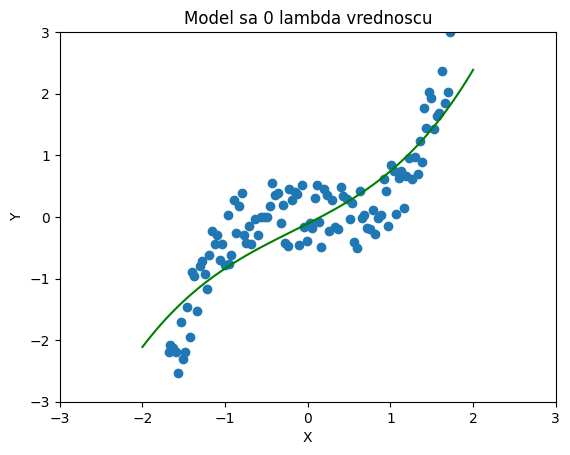


---------------------------
Lambda: 0.001
Originalne vrednosti (prve 3):
[ 0.43133888  0.5067108  -0.2766817 ]
Feature matrica (prva 3 reda):
[[ 0.43133888  0.18605323  0.08025199]
 [ 0.5067108   0.25675586  0.13010098]
 [-0.2766817   0.07655276 -0.02118075]]
Finalni loss: 0.11050


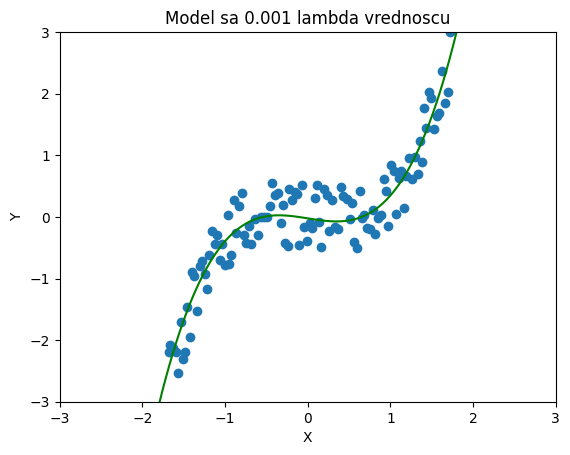


---------------------------
Lambda: 0.01
Originalne vrednosti (prve 3):
[ 0.43133888  0.5067108  -0.2766817 ]
Feature matrica (prva 3 reda):
[[ 0.43133888  0.18605323  0.08025199]
 [ 0.5067108   0.25675586  0.13010098]
 [-0.2766817   0.07655276 -0.02118075]]
Finalni loss: 0.19223


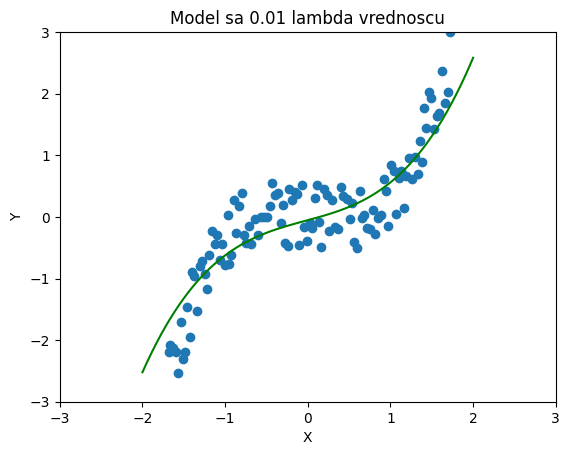


---------------------------
Lambda: 0.1
Originalne vrednosti (prve 3):
[ 0.43133888  0.5067108  -0.2766817 ]
Feature matrica (prva 3 reda):
[[ 0.43133888  0.18605323  0.08025199]
 [ 0.5067108   0.25675586  0.13010098]
 [-0.2766817   0.07655276 -0.02118075]]
Finalni loss: 0.12456


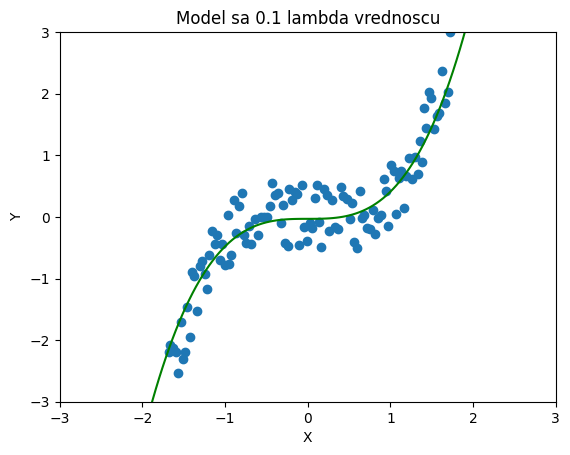


---------------------------
Lambda: 1
Originalne vrednosti (prve 3):
[ 0.43133888  0.5067108  -0.2766817 ]
Feature matrica (prva 3 reda):
[[ 0.43133888  0.18605323  0.08025199]
 [ 0.5067108   0.25675586  0.13010098]
 [-0.2766817   0.07655276 -0.02118075]]
Finalni loss: 0.18534


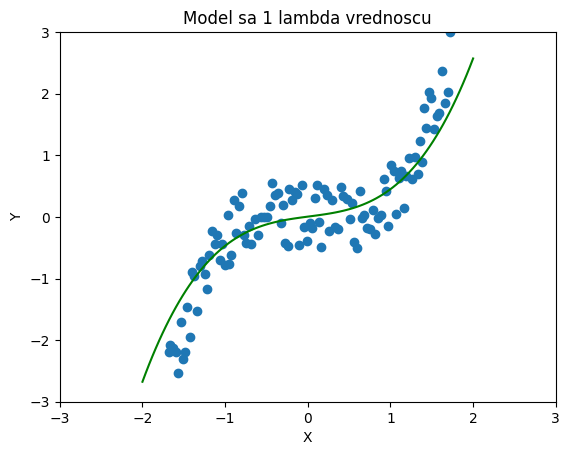


---------------------------
Lambda: 10
Originalne vrednosti (prve 3):
[ 0.43133888  0.5067108  -0.2766817 ]
Feature matrica (prva 3 reda):
[[ 0.43133888  0.18605323  0.08025199]
 [ 0.5067108   0.25675586  0.13010098]
 [-0.2766817   0.07655276 -0.02118075]]
Finalni loss: 0.53919


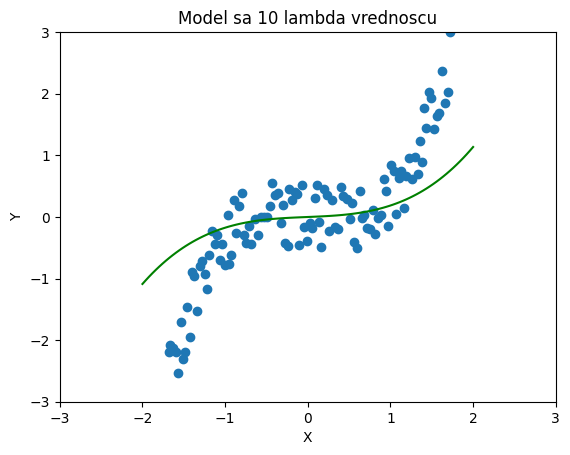


---------------------------
Lambda: 100
Originalne vrednosti (prve 3):
[ 0.43133888  0.5067108  -0.2766817 ]
Feature matrica (prva 3 reda):
[[ 0.43133888  0.18605323  0.08025199]
 [ 0.5067108   0.25675586  0.13010098]
 [-0.2766817   0.07655276 -0.02118075]]
Finalni loss: 0.92504


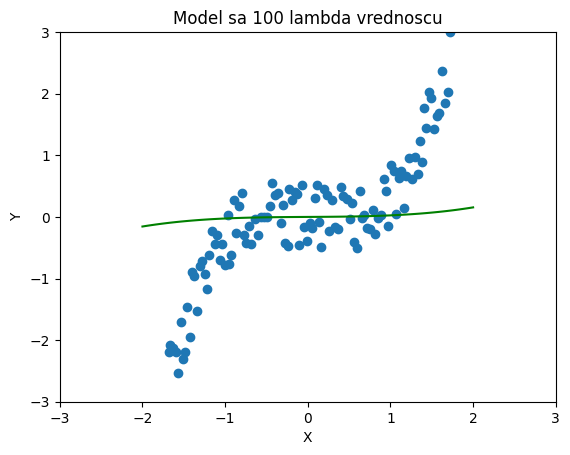

In [26]:
degrees = []
losses = []
lambdas = [0, 0.001, 0.01, 0.1, 1, 10, 100]
for lmbd in lambdas:
    print("\n---------------------------")
    print(f"Lambda: {lmbd}")
    x, y = make_features(3)
    model, final_loss = train_model(x, y, lmbd)
    plot_result(model, 3, lmbd)
    degrees.append(lmbd)
    losses.append(final_loss)

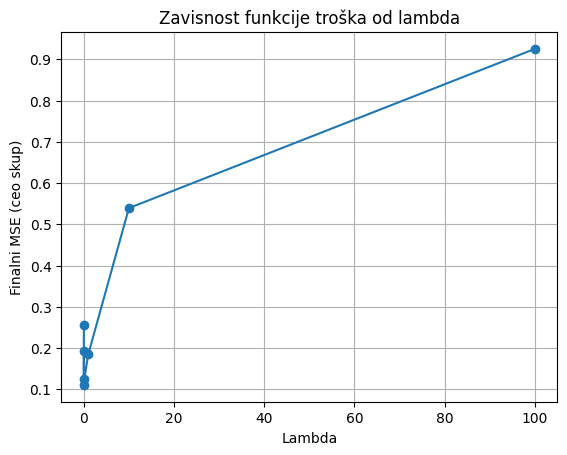

In [27]:
plt.plot(degrees, losses, marker='o')
plt.xlabel("Lambda")
plt.ylabel("Finalni MSE (ceo skup)")
plt.title("Zavisnost funkcije troška od lambda")
plt.grid()
plt.show()

Ovde se sa poprilicnom sigurnoscu moze reci da je lambda obrnuto srazmerna sa MSE. Takodje rast greske izgleda da prati logaritamsku krivu, sto ima smisla, jer sto je lambda veca, to je krajnji grafik blizi ravnoj liniji, i MSE ce se drzati oko 1.